# Feature Engineering Approaches for Location Features

#### Model A – One-Hot Encoding of ligand and receptor features 

Ligand and receptor locations are separate features.

Locations are one-hot encoded (OHE): if ligand_location = "golgi, plasma_membrane", the corresponding columns for golgi, plasma_membrane are set to 1, and all other location columns are set to 0.

#### Model B – Target Encoding of ligand and receptor features 

Similar to Model A, but instead of OHE, the combined ligand and receptor location feature is target encoded using CatBoost encoding.

Model C – Target Encoding of Raw Location Data, Ligand and Receptor location are combined to a single ligand_location feature

Uses the raw location column directly (e.g., "golgi, plasma_membrane; plasma_membrane") without splitting.

The column is target encoded.

Model D – One-Hot Encoding of Separated Locations - This model can be run using the run_log.py script in experiments

Ligand and receptor locations are first split into individual locations (e.g., "golgi, plasma_membrane" → "golgi", "plasma_membrane") and these individual features are encoded.

In [2]:
import os
os.chdir('/Users/rjay0256/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/University of Sydney/PhD projects/main/Cell Cell Communication/server/cell_cell_commuication/CCIDeconv/analysis')
print(os.getcwd()) # Verify the new directory
%cd ../

import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import extract_metrics

/Users/rjay0256/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/University of Sydney/PhD projects/main/Cell Cell Communication/server/cell_cell_commuication/CCIDeconv/analysis
/Users/rjay0256/Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/University of Sydney/PhD projects/main/Cell Cell Communication/server/cell_cell_commuication/CCIDeconv


In [71]:
# model A
! python experiments/run_logo.py \
     --data_path data/training_data/df_modelA.csv \
     --categorical_columns lr_pair,source,target,pathway_name,annotation,ligand.family,ligand.keyword,ligand.secreted_type,ligand.transmembrane,receptor.family,receptor.keyword,receptor.surfaceome_main,receptor.surfaceome_sub,receptor.adhesome,receptor.secreted_type,receptor.transmembrane \
     --group_column sample\
     --exclude_columns cyt_pval,cyt_pspatial,cyt_P1,sample,cell_pval,cell_P1,tissue,is_neurotransmitter,nuc_pval,nuc_pspatial,nuc_P1,ligand,receptor,labels\
     --spatial 
modelA_classifier  = joblib.load('results_classifier.joblib')
modelA_regressor  = joblib.load('results_regression.joblib')

(3273, 199)
              precision    recall  f1-score   support

           0       0.48      0.77      0.59        13
           1       0.91      0.74      0.82        43

    accuracy                           0.75        56
   macro avg       0.70      0.76      0.70        56
weighted avg       0.81      0.75      0.77        56

              precision    recall  f1-score   support

           0       0.07      1.00      0.14         6
           1       1.00      0.41      0.58       127

    accuracy                           0.44       133
   macro avg       0.54      0.70      0.36       133
weighted avg       0.96      0.44      0.56       133

              precision    recall  f1-score   support

           0       0.81      0.33      0.47        39
           1       0.49      0.89      0.63        28

    accuracy                           0.57        67
   macro avg       0.65      0.61      0.55        67
weighted avg       0.68      0.57      0.54        67

       

In [76]:
! # Model B
!python experiments/run_logo.py \
     --data_path data/training_data/df_modelB.csv \
     --categorical_columns lr_pair,source,target,pathway_name,annotation,ligand.family,ligand.keyword,ligand.secreted_type,ligand.transmembrane,receptor.family,receptor.keyword,receptor.surfaceome_main,receptor.surfaceome_sub,receptor.adhesome,receptor.secreted_type,receptor.transmembrane,ligand_location_cellchat,receptor_location_cellchat,ligand_location_hpa,receptor_location_hpa \
     --group_column sample\
     --exclude_columns cyt_pval,cyt_pspatial,cyt_P1,sample,cell_pval,cell_P1,tissue,is_neurotransmitter,nuc_pval,nuc_pspatial,nuc_P1,ligand,receptor,labels\
     --spatial 
modelB_classifier  = joblib.load('results_classifier.joblib')
modelB_regressor  = joblib.load('results_regression.joblib')

(3273, 22)
              precision    recall  f1-score   support

           0       0.47      0.69      0.56        13
           1       0.89      0.77      0.82        43

    accuracy                           0.75        56
   macro avg       0.68      0.73      0.69        56
weighted avg       0.79      0.75      0.76        56

              precision    recall  f1-score   support

           0       0.06      0.83      0.11         6
           1       0.98      0.40      0.57       127

    accuracy                           0.42       133
   macro avg       0.52      0.62      0.34       133
weighted avg       0.94      0.42      0.55       133

              precision    recall  f1-score   support

           0       0.84      0.54      0.66        39
           1       0.57      0.86      0.69        28

    accuracy                           0.67        67
   macro avg       0.71      0.70      0.67        67
weighted avg       0.73      0.67      0.67        67

        

In [79]:
! # Model C
!python experiments/run_logo.py \
     --data_path data/training_data/df_modelC.csv \
     --categorical_columns lr_pair,source,target,pathway_name,annotation,ligand.family,ligand.keyword,ligand.secreted_type,ligand.transmembrane,receptor.family,receptor.keyword,receptor.surfaceome_main,receptor.surfaceome_sub,receptor.adhesome,receptor.secreted_type,receptor.transmembrane,ligand.location_receptor.location, ligand_location_hpa_receptor_location_hpa\
     --exclude_columns cyt_pval,cyt_pspatial,cyt_P1,sample,cell_pval,cell_P1,tissue,is_neurotransmitter,nuc_pval,nuc_pspatial,nuc_P1,ligand,receptor,labels\
     --spatial 
modelC_classifier  = joblib.load('results_classifier.joblib')
modelC_regressor  = joblib.load('results_regression.joblib')

(3273, 20)
              precision    recall  f1-score   support

           0       0.42      0.77      0.54        13
           1       0.91      0.67      0.77        43

    accuracy                           0.70        56
   macro avg       0.66      0.72      0.66        56
weighted avg       0.79      0.70      0.72        56

              precision    recall  f1-score   support

           0       0.06      0.83      0.11         6
           1       0.98      0.37      0.54       127

    accuracy                           0.39       133
   macro avg       0.52      0.60      0.32       133
weighted avg       0.94      0.39      0.52       133

              precision    recall  f1-score   support

           0       0.88      0.59      0.71        39
           1       0.61      0.89      0.72        28

    accuracy                           0.72        67
   macro avg       0.75      0.74      0.72        67
weighted avg       0.77      0.72      0.71        67

        

In [99]:
# model D (final model)
! python experiments/run_logo.py \
     --data_path data/training_data/training_data.csv \
     --categorical_columns lr_pair,source,target,pathway_name,annotation,ligand.family,ligand.keyword,ligand.secreted_type,ligand.transmembrane,receptor.family,receptor.keyword,receptor.surfaceome_main,receptor.surfaceome_sub,receptor.adhesome,receptor.secreted_type,receptor.transmembrane \
     --group_column sample\
     --exclude_columns cyt_pval,cyt_pspatial,cyt_P1,sample,cell_pval,cell_P1,tissue,is_neurotransmitter,ligand_location_cellchat,receptor_location_cellchat,ligand_location_hpa,receptor_location_hpa,nuc_pval,nuc_pspatial,nuc_P1,ligand,receptor,labels\
     --spatial 
modelD_classifier  = joblib.load('results_classifier.joblib')
modelD_regressor  = joblib.load('results_regression.joblib')

(3273, 210)
              precision    recall  f1-score   support

           0       0.50      0.85      0.63        13
           1       0.94      0.74      0.83        43

    accuracy                           0.77        56
   macro avg       0.72      0.80      0.73        56
weighted avg       0.84      0.77      0.78        56

              precision    recall  f1-score   support

           0       0.06      0.83      0.12         6
           1       0.98      0.42      0.59       127

    accuracy                           0.44       133
   macro avg       0.52      0.63      0.35       133
weighted avg       0.94      0.44      0.56       133

              precision    recall  f1-score   support

           0       0.91      0.79      0.85        39
           1       0.76      0.89      0.82        28

    accuracy                           0.84        67
   macro avg       0.83      0.84      0.83        67
weighted avg       0.85      0.84      0.84        67

       

#### Plot the composite metrics across the different models

/var/folders/7q/h5n0rm1d6bs8yprnqc04_5740000gp/T/ipykernel_67274/3451838911.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='model', y='composite_metric', palette="Set2")


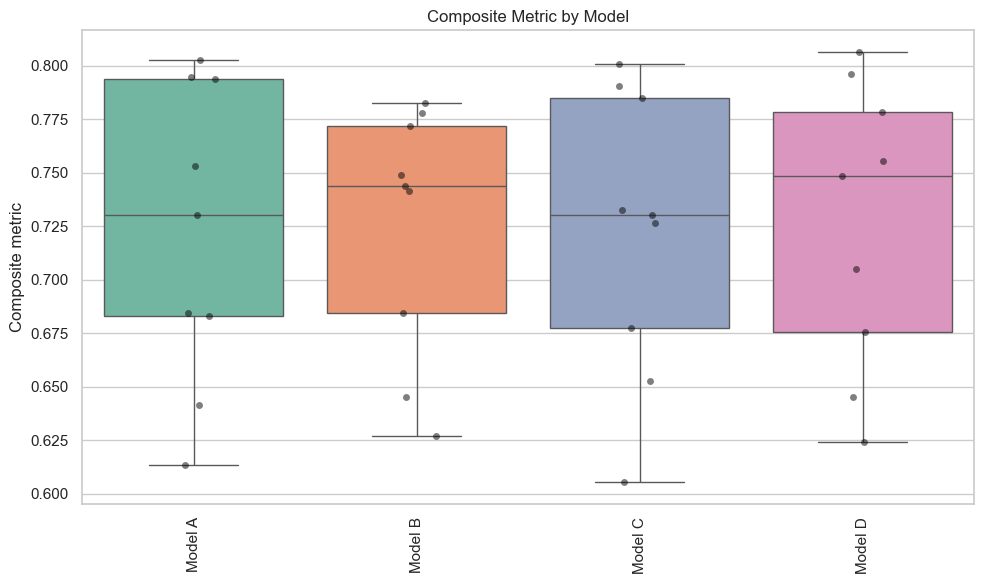

In [169]:
model_a = extract_metrics(modelA_classifier,modelA_regressor, 'model A')
model_b = extract_metrics(modelB_classifier,modelB_regressor, 'model B')
model_c = extract_metrics(modelC_classifier,modelC_regressor, 'model C')
model_d = extract_metrics(modelD_classifier,modelD_regressor, 'model D')
dfs = [model_a, model_b, model_c, model_d]
df = pd.concat([model_a, model_b, model_c, model_d], ignore_index=True)
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='model', y='composite_metric', palette="Set2")
sns.stripplot(data=df, x='model', y='composite_metric', color='black', alpha=0.5, jitter=True)

plt.ylabel('Composite metric')
plt.xlabel('')
plt.xticks(rotation=90)
plt.title('Composite Metric by Model')
plt.tight_layout()
plt.show()